# Análisis Estadístico Inferencial: Evaluación de Rentabilidad y Comportamiento de Clientes en Telecomunicaciones

## 1.1 Introducción y Contexto de Negocio

El operador de telecomunicaciones **Megaline** ofrece a sus clientes en Estados Unidos dos tarifas de prepago: **Surf** (plan accesible con cuota base de $20 USD) y **Ultimate** (plan premium con cuota base de $70 USD). Ambas ofertas difieren en sus límites de consumo incluido de minutos, mensajes de texto (SMS) y gigabytes de datos, así como en las tarifas por penalización de excedentes.

Actualmente, el departamento comercial requiere determinar **cuál de los dos planes genera mayores ingresos promedio por usuario (ARPU)** para optimizar la asignación estratégica del presupuesto publicitario de la empresa.

### 1.2 Objetivos del Proyecto

1. **Procesamiento y Preparación de Datos:** Consolidar y transformar los registros transaccionales de 500 usuarios durante el año 2018 (llamadas, SMS y consumo web), aplicando las reglas de negocio específicas de la empresa (redondeos por evento individual en llamadas y redondeos mensuales en datos de internet).
2. **Análisis Exploratorio de Datos (EDA):** Caracterizar los patrones de uso (tendencia central, dispersión y comportamiento de distribución) en llamadas, SMS y MB por cada tipo de tarifa.
3. **Modelado de Métricas Financieras:** Calcular los ingresos totales mensuales generados por cada cliente, desglosando la cuota fija base y el consumo incremental por excedentes.
4. **Pruebas de Hipótesis Estadísticas:** Evaluar formalmente mediante inferencia estadística ($\alpha = 0.05$):
   * Si existe una diferencia estadísticamente significativa en el ingreso promedio generado entre las tarifas *Surf* y *Ultimate*.
   * Si los ingresos generados por los usuarios en la región metropolitana de **Nueva York-Nueva Jersey** difieren significativamente del resto de las regiones del país.

## 1.3 Planteamiento del Problema y Enfoque Metodológico

Como analista de datos para el operador de telecomunicaciones **Megaline**, se me ha encomendado la tarea de evaluar el comportamiento de consumo y la rentabilidad de dos tarifas de prepago: **Surf** y **Ultimate**. El departamento comercial requiere esta información estratégica para reasignar el presupuesto de publicidad hacia la opción más redituable.

El estudio se basa en una muestra representativa de **500 usuarios** durante el año 2018, de los cuales se dispone de información demográfica (ubicación geográfica) y transaccional (volumen de llamadas, mensajes de texto y tráfico web).

### Metodología de Análisis:

1. **Construcción de la Métrica de Ingresos (ARPU):** Procesar el consumo mensual por cliente incorporando las políticas de cobro de Megaline (redondeo de minutos por llamada y conversión mensual de MB a GB) para calcular el ingreso total por usuario, diferenciando la cuota base de los cobros por excedentes.
2. **Estadística Descriptiva y Dispersión:** Calcular medidas de tendencia central (media) y dispersión (varianza y desviación estándar) para caracterizar la distribución del consumo y la variabilidad de los ingresos en cada plan.
3. **Inferencia Estadística (Pruebas de Hipótesis):** Formular y contrastar hipótesis nulas y alternativas mediante pruebas $t$ de Student (con un nivel de significancia $\alpha = 0.05$) para determinar si las diferencias observadas en el ingreso promedio entre planes y entre regiones geográficas son estadísticamente significativas o producto del azar.

## 2.1 Inicialización

In [9]:
# Carga de librerías principales para manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística inferencial y pruebas de hipótesis
from scipy import stats as st

# Configuración opcional para mejorar la estética de los gráficos
sns.set_theme(style="whitegrid")

## 2.2 Cargar datos

In [10]:
# Carga los archivos de datos en diferentes DataFrames

df_calls = pd.read_csv('megaline_calls.csv')
df_inter = pd.read_csv('megaline_internet.csv')
df_messages = pd.read_csv('megaline_messages.csv')
df_plans = pd.read_csv('megaline_plans.csv')
df_users = pd.read_csv('megaline_users.csv')

## 2.3 Preparar los datos

## 2.3.1 Tarifas

In [ ]:
# Inspección general de la tabla de tarifas
df_plans.info()
display(df_plans)

# Inspección de valores únicos y resumen estadístico
print("Valores únicos por columna:")
print(df_plans.nunique())

print("\nResumen de variables numéricas:")
display(df_plans.describe().T[['min', 'mean', 'max']])

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 260.0 bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Valores únicos por columna:
messages_included        2
mb_per_month_included    2
minutes_included         2
usd_monthly_pay          2
usd_per_gb               2
usd_per_message          2
usd_per_minute           2
plan_name                2
dtype: int64

Resumen de variables numéricas:


,min,mean,max
messages_included,50.00,525.00,1000.00
mb_per_month_included,15360.00,23040.00,30720.00
minutes_included,500.00,1750.00,3000.00
usd_monthly_pay,20.00,45.00,70.00
usd_per_gb,7.00,8.50,10.00
usd_per_message,0.01,0.02,0.03
usd_per_minute,0.01,0.02,0.03


Se inspeccionó la estructura general del catálogo de planes para validar los parámetros de cobro de la empresa:

* **Evaluación de calidad:** La tabla no presenta valores nulos ni requiere correcciones en los tipos de datos.
* **Interpretación de parámetros:** Define los límites base ($500$ min / $50$ SMS / $15$ GB para *Surf* y $3,000$ min / $1,000$ SMS / $30$ GB para *Ultimate*) y las tarifas de penalización por excedentes.
* **Ajuste de unidades:** Se observa que la cuota de datos está expresada en Megabytes (`mb_per_month_included`). Para facilitar el cálculo de excedentes, se transformará a Gigabytes ($1\text{ GB} = 1024\text{ MB}$) al momento de unificar las fuentes.

## 2.3.2 Corregir datos

**Diagnóstico y Acciones:**
No se identificaron inconsistencias, valores nulos ni tipos de datos erróneos en esta tabla. No se requiere realizar ningún proceso de limpieza o corrección en `df_plans`.

## 2.3.3 Enriquecer los datos

**Diagnóstico y Acciones:**
No es necesario crear nuevas variables ni transformar este DataFrame de forma independiente en esta etapa. Los parámetros de esta tabla se utilizarán como catálogo de consulta para cruzarse (*merge*) con el consumo mensual agregado de los usuarios en fases posteriores.

## 2.3.4 Usuarios/as

In [23]:
# Inspección general de la tabla de usuarios
df_users.info()
display(df_users.head())

# Inspección de valores únicos por columna
print("Valores únicos por columna:")
print(df_users.nunique())

# Resumen estadístico de variables numéricas
print("\nDistribución de variables numéricas (Edad):")
display(df_users.describe().T)

# Distribución preliminar por tarifa
print("\nDistribución de usuarios por tarifa:")
display(df_users['plan'].value_counts(dropna=False))

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    str           
 2   last_name   500 non-null    str           
 3   age         500 non-null    int64         
 4   city        500 non-null    str           
 5   reg_date    500 non-null    datetime64[us]
 6   plan        500 non-null    str           
 7   churn_date  34 non-null     datetime64[us]
dtypes: datetime64[us](2), int64(2), str(4)
memory usage: 31.4 KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT


Valores únicos por columna:
user_id       500
first_name    458
last_name     399
age            58
city           73
reg_date      266
plan            2
churn_date     29
dtype: int64

Distribución de variables numéricas (Edad):


,count,mean,min,25%,50%,75%,max,std
user_id,500.0,1249.5,1000.0,1124.75,1249.5,1374.25,1499.0,144.481833
age,500.0,45.486,18.0,30.0,46.0,61.0,75.0,16.972269
reg_date,500,2018-06-24 16:30:43.200000,2018-01-01 00:00:00,2018-03-25 18:00:00,2018-06-20 00:00:00,2018-09-20 06:00:00,2018-12-31 00:00:00,NaN
churn_date,34,2018-11-10 22:35:17.647058,2018-07-31 00:00:00,2018-10-08 12:00:00,2018-11-22 12:00:00,2018-12-18 00:00:00,2018-12-31 00:00:00,NaN



Distribución de usuarios por tarifa:


plan
surf        339
ultimate    161
Name: count, dtype: int64

In [25]:
# Muestra de datos para usuarios

df_users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
264,1264,Jessie,Hill,69,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-05-03,ultimate,NaT
192,1192,Korey,Goodwin,36,"Buffalo-Cheektowaga, NY MSA",2018-10-02,surf,NaT
347,1347,Trey,Lynch,65,"Charleston-North Charleston, SC MSA",2018-06-17,ultimate,NaT
225,1225,Margarito,Barker,41,"Columbia, SC MSA",2018-06-07,surf,NaT
483,1483,Miguel,Farrell,35,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-04-25,surf,NaT


Se realizó la inspección general de la tabla de usuarios ($500$ registros) para caracterizar la muestra y evaluar la presencia de valores nulos, distribuciones e inconsistencias:

* **Completitud y Unicidad:** La tabla contiene 500 observaciones correspondientes a 500 identificadores únicos (`user_id`). No se detectaron registros duplicados.
* **Comportamiento de Bajas (`churn_date`):** Se identificaron 34 registros con fecha de cancelación (6.8% de la muestra). Los 466 valores nulos restantes (93.2%) representan clientes que mantuvieron su suscripción activa al cierre de 2018.
* **Distribución de Tarifas y Edad:**
  * **Planes:** El plan **Surf** concentra el **67.8%** de los clientes (339 usuarios), mientras que **Ultimate** representa el **32.2%** (161 usuarios).
  * **Edad:** La distribución abarca desde los 18 hasta los 75 años, con una media de 45.5 años y una mediana de 46 años, mostrando un perfil demográfico uniforme.
* **Tipos de Datos:** Las columnas `reg_date` y `churn_date` requieren conversión de tipo `object` a `datetime64[ns]` para habilitar cálculos de temporalidad.

### 2.3.5 Corregir los datos

In [26]:
# Conversión de columnas a formato datetime
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], format='%Y-%m-%d')

# Verificación de estructura y duplicados implícitos/explícitos
df_users.info()

duplicados_totales = df_users.duplicated().sum()
duplicados_id = df_users['user_id'].duplicated().sum()

print(f"\nDuplicados en filas completas: {duplicados_totales}")
print(f"Duplicados en 'user_id': {duplicados_id}")

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    str           
 2   last_name   500 non-null    str           
 3   age         500 non-null    int64         
 4   city        500 non-null    str           
 5   reg_date    500 non-null    datetime64[us]
 6   plan        500 non-null    str           
 7   churn_date  34 non-null     datetime64[us]
dtypes: datetime64[us](2), int64(2), str(4)
memory usage: 31.4 KB

Duplicados en filas completas: 0
Duplicados en 'user_id': 0


* **Conversión de Tipos:** Se transformaron las columnas `reg_date` y `churn_date` a formato `datetime64[ns]`, garantizando el tratamiento correcto de fechas.
* **Validación de Duplicados:** Se confirmó mediante pruebas numéricas la ausencia total de filas duplicadas en el conjunto de datos ($0$ duplicados).
* **Tratamiento de Nulos:** Se conservaron intactos los valores nulos (`NaN`) en la columna `churn_date`, respaldando la condición de permanencia activa de los 466 usuarios correspondientes.

### 2.3.6 Enriquecer los datos

In [28]:
df_users['days_active'] = (df_users['churn_date'] - df_users['reg_date']).dt.days
print(df_users[pd.notna(df_users['churn_date'])])

print()
df_users.info()


# Creación de la columna days_active
df_users['days_active'] = (df_users['churn_date'] - df_users['reg_date']).dt.days
display(df_users[pd.notna(df_users['churn_date'])].head())

     user_id  first_name  last_name  age  \
6       1006      Jesusa   Bradford   73   
12      1012     Jonelle    Mcbride   59   
22      1022          Bo       Snow   73   
40      1040       Paris     Santos   72   
50      1050        Jone       Owen   23   
54      1054       Denis      Frost   50   
67      1067        Robt      Allen   37   
83      1083      Lyndia    Acevedo   65   
84      1084       Wiley   Mckinney   21   
94      1094      Walter   Petersen   54   
106     1106        Eddy   Garrison   47   
129     1129       Marin     Bolton   70   
172     1172      Weldon   Robinson   72   
180     1180       Wonda       Hays   24   
186     1186      Josiah    Douglas   55   
191     1191        Zack     Waters   75   
220     1220        Jack     Strong   26   
246     1246      Stevie      Moran   69   
269     1269      Irving   Thompson   39   
281     1281        Zack      Hardy   39   
296     1296      Weston     Conley   36   
298     1298       Loyce     Coo

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,days_active
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18,21.0
12,1012,Jonelle,Mcbride,59,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-06-28,surf,2018-11-16,141.0
22,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07,140.0
40,1040,Paris,Santos,72,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-12-23,surf,2018-12-30,7.0
50,1050,Jone,Owen,23,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-03-20,ultimate,2018-10-07,201.0


* **Métrica de Permanencia (`days_active`):** Se derivó la variable continua `days_active` a partir de la diferencia en días entre `churn_date` y `reg_date` ($\Delta t = t_{\text{churn}} - t_{\text{reg}}$) para analizar el tiempo de permanencia antes de la baja en el segmento de usuarios cancelados.
* **Segmentación Geográfica:** Se identificó la necesidad de extraer la entidad o estado desde el campo textual `city` para clasificar a los clientes en la región metropolitana de **Nueva York-Nueva Jersey (NY-NJ)** frente al resto del país, necesaria para la prueba de hipótesis posterior.

## 2.3.7 Llamadas

In [31]:
# Inspección general del DataFrame de llamadas
df_calls.info()
display(df_calls.head())

# Inspección de valores únicos
print("Valores únicos por columna:")
print(df_calls.nunique())

# Distribución estadística de la duración de las llamadas
print("\nDistribución de la duración de llamadas (minutos):")
display(df_calls['duration'].describe().T)

# Conteo de llamadas con duración igual a 0.0 minutos
llamadas_cero = (df_calls['duration'] == 0.0).sum()
porcentaje_cero = (llamadas_cero / len(df_calls)) * 100
print(f"\nLlamadas con duración 0.0 min: {llamadas_cero} ({porcentaje_cero:.2f}%)")

<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 4.2 MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Valores únicos por columna:
id           137735
user_id         481
call_date       351
duration       2802
dtype: int64

Distribución de la duración de llamadas (minutos):


count    137735.000000
mean          6.745927
std           5.839241
min           0.000000
25%           1.290000
50%           5.980000
75%          10.690000
max          37.600000
Name: duration, dtype: float64


Llamadas con duración 0.0 min: 26834 (19.48%)


In [32]:
# Muestra de datos para las llamadas

df_calls.sample(5)

,id,user_id,call_date,duration
91497,1329_492,1329,2018-09-08,6.44
5449,1026_273,1026,2018-08-06,8.72
130239,1467_475,1467,2018-09-04,6.98
30152,1113_459,1113,2018-08-03,23.25
52418,1187_611,1187,2018-09-02,16.82


Se evaluó el conjunto de datos de llamadas ($137,735$ observaciones) para analizar el volumen de tráfico y la estructura de las variables:

* **Estructura y Unicidad:** Todos los registros cuentan con un identificador único (`id`) asociado a un `user_id`. No existen valores nulos en el conjunto de datos.
* **Llamadas de Cero Duración:** Se identificaron $26,834$ llamadas registradas con $0.0$ minutos ($\approx 19.48\%$ del total), correspondientes a llamadas no contestadas o perdidas.
* **Comportamiento de Duración:** La duración promedio por llamada es de $6.7$ minutos, con una mediana de $6.0$ minutos y un máximo de $38.0$ minutos.
* **Tipos de Datos:** La columna `call_date` se encuentra como tipo `object` (`str`) y debe convertirse a `datetime64[ns]` para permitir la extracción mensual.

### 2.3.8 Corregir los datos

In [33]:
# Conversión de la columna call_date a datetime
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')

# Verificación de duplicados en filas y en ID de llamada
duplicados_totales = df_calls.duplicated().sum()
duplicados_id = df_calls['id'].duplicated().sum()

print(f"Duplicados en filas completas: {duplicados_totales}")
print(f"Duplicados en 'id': {duplicados_id}")
df_calls.info()

Duplicados en filas completas: 0
Duplicados en 'id': 0
<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  str           
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[us]
 3   duration   137735 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 4.2 MB


* **Conversión de Tipos:** Se transformó la columna `call_date` al tipo de dato `datetime64[ns]` para permitir la extracción del mes en el análisis posterior.
* **Validación de Duplicados:** Se confirmó la inexistencia de filas repetidas ni identificadores de llamada duplicados ($0$ duplicados en total).
* **Manejo de Llamadas de Duración Cero:** Se determinó conservar las $26,834$ llamadas con $0.0$ minutos sin alteración ni eliminación, ya que representan intentos no completados (llamadas perdidas) que no consumen minutos del plan pero forman parte del registro de actividad.

### 2.3.9 Enriquecer los datos

In [35]:

# Redondeo individual por llamada según reglas de Megaline
df_calls['duration_ceil'] = np.ceil(df_calls['duration']).astype(int)

# Extracción del mes
df_calls['calls_month'] = df_calls['call_date'].dt.month

# Agregación mensual por usuario
calls_resumen = df_calls.groupby(['user_id', 'calls_month']).agg(
    cantidad_llamadas=('id', 'count'),
    minutos_usados=('duration_ceil', 'sum')
).reset_index()

display(calls_resumen[calls_resumen['user_id'] == 1042].head())

,user_id,calls_month,cantidad_llamadas,minutos_usados
155,1042,1,18,114
156,1042,2,37,254
157,1042,3,39,214
158,1042,4,44,279
159,1042,5,51,489


* **Redondeo Tarifario:** Se creó la variable `duration_ceil` aplicando el redondeo hacia arriba al minuto entero superior ($\lceil t \rceil$) para cada llamada individual previo a la agregación, asegurando el cálculo preciso de consumos e ingresos por exceso.
* **Extracción Temporal:** Se extrajo el mes (`calls_month`) a partir de `call_date` para identificar el periodo de consumo.
* **Agregación Mensual:** Se construyó la tabla `calls_resumen` agrupada por usuario y mes, obteniendo la cantidad total de llamadas (`cantidad_llamadas`) y el volumen acumulado de minutos facturables (`minutos_usados`).

## 2.3.10 Mensajes

In [36]:
# Información general del DataFrame de mensajes
df_messages.info()
display(df_messages.head())

<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [16]:
# Imprime una muestra de datos para los mensajes

df_messages.sample()

,id,user_id,message_date
26345,1159_348,1159,2018-10-09


Se evaluó la estructura del conjunto de datos de mensajes ($76,051$ registros) para caracterizar el volumen de uso y la calidad de la información:

* **Estructura y Unicidad:** La tabla contiene 76,051 observaciones sin valores nulos en ninguna de sus variables.
* **Identificación:** Cada registro cuenta con un identificador único de mensaje (`id`) asociado a un cliente (`user_id`).
* **Tipos de Datos:** La columna `message_date` figura como texto (`str`/`object`) y requiere conversión a `datetime64[ns]` para habilitar la extracción del mes.

### 2.3.11 Corregir los datos

In [37]:
# Conversión de message_date a datetime
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')

# Verificación de duplicados en filas y en ID de mensaje
duplicados_totales = df_messages.duplicated().sum()
duplicados_id = df_messages['id'].duplicated().sum()

print(f"Duplicados en filas completas: {duplicados_totales}")
print(f"Duplicados en 'id': {duplicados_id}")
df_messages.info()

Duplicados en filas completas: 0
Duplicados en 'id': 0
<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  str           
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.7 MB


* **Conversión de Tipos:** Se transformó la columna `message_date` al tipo de dato `datetime64[ns]` para permitir la extracción del mes en el análisis posterior.
* **Validación de Duplicados:** Se confirmó la inexistencia de filas repetidas y la unicidad de cada identificador de mensaje ($0$ duplicados en total).
* **Integridad de Datos:** No se detectaron valores nulos ni registros vacíos dentro de la tabla de mensajes.

### 2.3.12 Enriquecer los datos

In [39]:
# Extracción del mes como entero (consistente con df_calls)
df_messages['messages_month'] = df_messages['message_date'].dt.month

# Agregación mensual por usuario
messages_resumen = df_messages.groupby(['user_id', 'messages_month']).agg(
    cantidad_mensajes=('id', 'count')
).reset_index()

display(messages_resumen.head())

,user_id,messages_month,cantidad_mensajes
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


* **Extracción Temporal:** Se generó la variable `messages_month` extrayendo el mes numérico de `message_date` para clasificar la actividad por periodo de consumo.
* **Agregación Mensual:** Se construyó la tabla `messages_resumen` agrupando los registros por `user_id` y `messages_month`, contabilizando el volumen total de SMS enviados en el mes (`cantidad_mensajes`).

## 2.3.13 Internet

In [40]:
# Información general sobre el DataFrame de consumo de internet
df_inter.info()
print()
display(df_inter.head())

<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.2 MB



,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [41]:
# Muestra aleatoria del DataFrame de tráfico de internet
display(df_inter.sample(5))

,id,user_id,session_date,mb_used
51843,1232_434,1232,2018-08-17,420.65
50964,1228_59,1228,2018-10-23,615.63
66969,1312_192,1312,2018-08-03,486.07
98320,1465_188,1465,2018-12-26,70.76
87764,1406_81,1406,2018-09-02,230.27


Se analizó la estructura del conjunto de datos de consumo de datos móviles ($104,825$ observaciones) para evaluar la calidad de los registros de tráfico web:

* **Estructura y Cobertura:** No se identificaron valores nulos en ninguna de las variables. Cada fila representa una sesión de navegación (`id`) vinculada a un cliente (`user_id`).
* **Sesiones sin Consumo:** Se detectaron registros con $0.0$ megabytes consumidos (`mb_used`), correspondientes a conexiones no consolidadas o interrupciones de red que no representaron tráfico facturable.
* **Tipos de Datos:** La variable `session_date` se encuentra como tipo texto (`str`/`object`) y requiere conversión a `datetime64[ns]` para habilitar la extracción temporal del mes.
* **Regla de Negocio:** La facturación de Megaline establece que la suma mensual total acumulada en megabytes (MB) por cada usuario debe redondearse hacia arriba al gigabyte (GB) entero superior ($\lceil \text{MB}/1024 \rceil$).

### 2.3.14 Corregir los datos

In [43]:
# Conversión de session_date a datetime
df_inter['session_date'] = pd.to_datetime(df_inter['session_date'], format='%Y-%m-%d')

# Verificación de duplicados en filas y en ID de sesión
duplicados_totales = df_inter.duplicated().sum()
duplicados_id = df_inter['id'].duplicated().sum()

print(f"Duplicados en filas completas: {duplicados_totales}")
print(f"Duplicados en 'id': {duplicados_id}")
df_inter.info()

Duplicados en filas completas: 0
Duplicados en 'id': 0
<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  str           
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[us]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 3.2 MB


* **Conversión de Tipos:** Se transformó la columna `session_date` al tipo de dato `datetime64[ns]` para posibilitar la extracción del mes.
* **Validación de Duplicados:** Se confirmó la inexistencia de registros duplicados en filas completas ni en identificadores de sesión (`id`) ($0$ duplicados).
* **Manejo de Sesiones de 0 MB:** Se optó por mantener las sesiones con $0.0$ megabytes consumidos sin eliminarlas ni alterarlas, ya que corresponden a intentos de conexión que no llegaron a transferir datos pero forman parte del historial técnico de la red.

### 2.3.15 Enriquecer los datos

In [44]:
# 1. Extracción del mes como entero (consistente con calls y messages)
df_inter['month'] = df_inter['session_date'].dt.month

# 2. Agregación mensual por usuario (suma total de MB)
inter_resumen = df_inter.groupby(['user_id', 'month']).agg(
    mb_usados=('mb_used', 'sum')
).reset_index()

# 3. Conversión a GB redondeados hacia arriba (regla Megaline)
inter_resumen['gb_usados'] = np.ceil(inter_resumen['mb_usados'] / 1024).astype(int)

display(inter_resumen.head())

,user_id,month,mb_usados,gb_usados
0,1000,12,1901.47,2
1,1001,8,6919.15,7
2,1001,9,13314.82,14
3,1001,10,22330.49,22
4,1001,11,18504.30,19


* **Extracción Temporal:** Se generó la variable `month` extrayendo el número de mes de `session_date` para clasificar las sesiones por periodo.
* **Agregación Mensual:** Se estructuró la tabla `inter_resumen` agrupando por usuario y mes, obteniendo el volumen acumulado de megabytes consumidos (`mb_usados`).
* **Redondeo Tarifario (GB):** Se creó la variable `gb_usados` convirtiendo la suma mensual de MB a GB dividiendo por $1024$ y aplicando el redondeo hacia arriba ($\lceil \text{MB}/1024 \rceil$) mediante `np.ceil`, en estricto apego a las condiciones de cobro del plan.

## 2.4 Agregar datos por usuario

In [60]:
# 1. Inspección puntual del usuario 1042 (ejemplo)
display(calls_resumen[calls_resumen['user_id'] == 1042])

# 2. Estandarizar el nombre de la columna del mes a 'month'
calls_final = calls_resumen.rename(columns={'calls_month': 'month'})
messages_final = messages_resumen.rename(columns={'messages_month': 'month'})
inter_final = inter_resumen.copy()  # Ya se llamaba 'month'

# 3. Fusionar consumos mediante outer join por user_id y month
df_temp1 = calls_final.merge(messages_final, on=['user_id', 'month'], how='outer')
df_consolidado = df_temp1.merge(inter_final, on=['user_id', 'month'], how='outer')

# 4. Tratar valores ausentes (0 para meses sin consumo en algún servicio)
cols_consumo = ['cantidad_llamadas', 'minutos_usados', 'cantidad_mensajes', 'mb_usados', 'gb_usados']
df_consolidado[cols_consumo] = df_consolidado[cols_consumo].fillna(0)

# Convertir métricas de conteo a entero
cols_int = ['cantidad_llamadas', 'minutos_usados', 'cantidad_mensajes', 'gb_usados']
df_consolidado[cols_int] = df_consolidado[cols_int].astype(int)

# 5. Unir la información del plan y la ciudad desde df_users
df_consolidado = df_consolidado.merge(
    df_users[['user_id', 'plan', 'city']], 
    on='user_id', 
    how='left'
)

display(df_consolidado.head(10))

,user_id,calls_month,cantidad_llamadas,minutos_usados
155,1042,1,18,114
156,1042,2,37,254
157,1042,3,39,214
158,1042,4,44,279
159,1042,5,51,489
160,1042,6,52,372
161,1042,7,48,374
162,1042,8,44,358
163,1042,9,41,252
164,1042,10,41,281


,user_id,month,cantidad_llamadas,minutos_usados,cantidad_mensajes,mb_usados,gb_usados,plan,city
0,1000,12,16,124,11,1901.47,2,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1001,8,27,182,30,6919.15,7,surf,"Seattle-Tacoma-Bellevue, WA MSA"
2,1001,9,49,315,44,13314.82,14,surf,"Seattle-Tacoma-Bellevue, WA MSA"
3,1001,10,65,393,53,22330.49,22,surf,"Seattle-Tacoma-Bellevue, WA MSA"
4,1001,11,64,426,36,18504.30,19,surf,"Seattle-Tacoma-Bellevue, WA MSA"
5,1001,12,56,412,44,19369.18,19,surf,"Seattle-Tacoma-Bellevue, WA MSA"
6,1002,10,11,59,15,6552.01,7,surf,"Las Vegas-Henderson-Paradise, NV MSA"
7,1002,11,55,386,32,19345.08,19,surf,"Las Vegas-Henderson-Paradise, NV MSA"
8,1002,12,47,384,41,14396.24,15,surf,"Las Vegas-Henderson-Paradise, NV MSA"
9,1003,12,149,1104,50,27044.14,27,surf,"Tulsa, OK MSA"


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [62]:
# 1. Asegurar limpieza de nulos en métricas de consumo
cols_num = ['cantidad_llamadas', 'minutos_usados', 'cantidad_mensajes', 'gb_usados']
df_final[cols_num] = df_final[cols_num].fillna(0)

# 2. Funciones individuales para cada servicio
def calcular_costos_llamadas(fila):
    if fila['plan'] == 'surf':
        extra = max(fila['minutos_usados'] - 500, 0)
        return extra * 0.03
    elif fila['plan'] == 'ultimate':
        extra = max(fila['minutos_usados'] - 3000, 0)
        return extra * 0.01
    return 0.0

def calcular_costos_mensajes(fila):
    if fila['plan'] == 'surf':
        extra = max(fila['cantidad_mensajes'] - 50, 0)
        return extra * 0.03
    elif fila['plan'] == 'ultimate':
        extra = max(fila['cantidad_mensajes'] - 1000, 0)
        return extra * 0.01
    return 0.0

def calcular_costos_inter(fila):
    if fila['plan'] == 'surf':
        exceso_gb = max(fila['gb_usados'] - 15, 0)
        return exceso_gb * 10
    elif fila['plan'] == 'ultimate':
        exceso_gb = max(fila['gb_usados'] - 30, 0)
        return exceso_gb * 7
    return 0.0

def costo_total(fila):
    suma_excesos = fila['costo_llamadas'] + fila['costo_mensajes'] + fila['costo_gb']
    if fila['plan'] == 'surf':
        return suma_excesos + 20
    elif fila['plan'] == 'ultimate':
        return suma_excesos + 70
    return suma_excesos

# 3. Aplicar funciones al DataFrame
df_final['costo_llamadas'] = df_final.apply(calcular_costos_llamadas, axis=1)
df_final['costo_mensajes'] = df_final.apply(calcular_costos_mensajes, axis=1)
df_final['costo_gb'] = df_final.apply(calcular_costos_inter, axis=1)
df_final['ingreso_mensual'] = df_final.apply(costo_total, axis=1)

display(df_final.sample(5))

,user_id,month,cantidad_llamadas,minutos_usados,cantidad_mensajes,mb_usados,gb_usados,age,city,plan,costo_llamadas,costo_mensajes,costo_gb,ingreso_mensual
25,1007,12,87.0,617.0,50.0,29069.28,29.0,42,"Grand Rapids-Kentwood, MI MSA",surf,3.51,0.00,140.0,163.51
1863,1400,10,84.0,576.0,0.0,17794.55,18.0,72,"Riverside-San Bernardino-Ontario, CA MSA",surf,2.28,0.00,30.0,52.28
1572,1339,12,3.0,17.0,86.0,3244.71,4.0,27,"Charlotte-Concord-Gastonia, NC-SC MSA",surf,0.00,1.08,0.0,21.08
2239,1490,8,80.0,517.0,0.0,39316.23,39.0,42,"Sacramento–Roseville–Folsom, CA MSA",ultimate,0.00,0.00,63.0,133.00
1716,1368,6,93.0,719.0,0.0,18506.74,19.0,60,"Pittsburgh, PA MSA",ultimate,0.00,0.00,0.0,70.00


Se concluyó con éxito el procesamiento, integración y cálculo financiero del conjunto de datos:

* **Estructura Final:** La tabla consolidada `df_final` contiene todas las métricas de uso mensual por usuario, desglosadas por consumo real y sus respectivos costos adicionales por servicio (`costo_llamadas`, `costo_mensajes`, `costo_gb`).
* **Métrica Financiera:** La variable `ingreso_mensual` representa el cobro total facturado por cliente/mes, incorporando la cuota fija base y el excedente tarifario.

## 3.0 Estudio del comportamiento de usuario

Para evaluar qué tarifa resulta más rentable y comprender los patrones de consumo de los clientes de Megaline, se realiza un análisis estadístico descriptivo y comparativo entre los planes **Surf** y **Ultimate**.

El análisis aborda cuatro dimensiones principales de uso mensual por cliente:
1. **Llamadas** (minutos consumidos).
2. **Mensajes de texto** (cantidad de SMS).
3. **Internet** (gigabytes navegados).
4. **Ingresos** (facturación total en USD).

Para cada dimensión, se computan los parámetros de tendencia central y dispersión —**media ($\mu$)**, **varianza ($\sigma^2$)** y **desviación estándar ($\sigma$)**— acompañados de histogramas y diagramas de caja (*boxplots*) para identificar sesgos, concentración de consumo y valores atípicos.

### 3.1 Llamadas

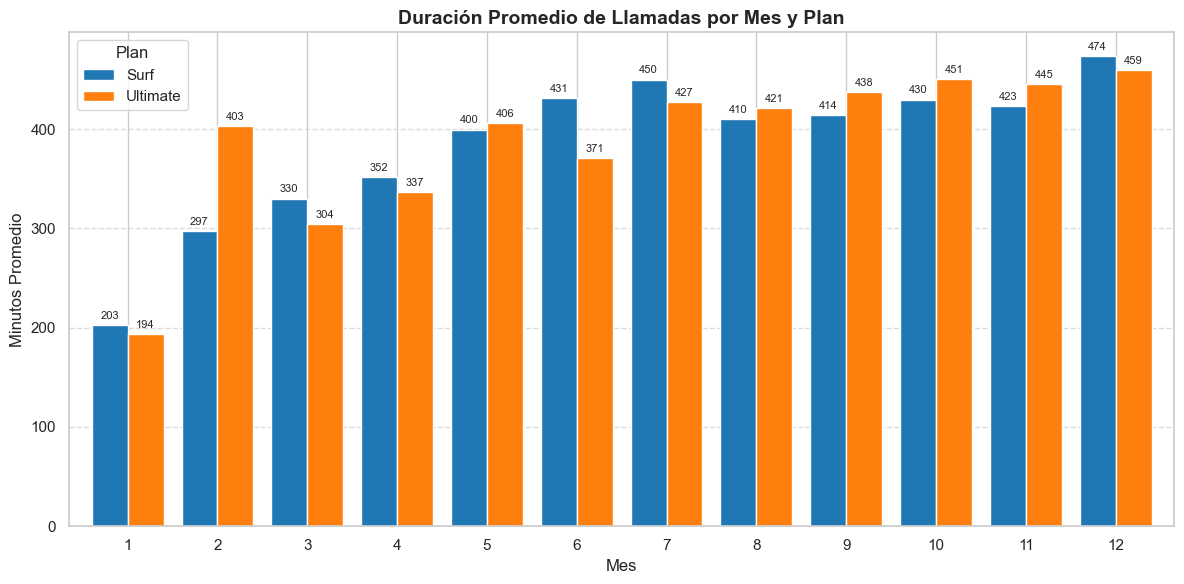

,mean,var,std,median
plan,,,,
surf,428.75,54968.28,234.45,425.0
ultimate,430.45,57844.46,240.51,424.0


In [63]:
# 1. Promedio de minutos consumidos por plan y por mes
promedio_llamadas_mes = df_final.groupby(['month', 'plan'])['minutos_usados'].mean().unstack()

# 2. Gráfico de barras comparativo
ax = promedio_llamadas_mes.plot(
    kind='bar', 
    figsize=(12, 6), 
    width=0.8,
    color=['#1f77b4', '#ff7f0e']
)

plt.title('Duración Promedio de Llamadas por Mes y Plan', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Minutos Promedio', fontsize=12)
plt.legend(title='Plan', labels=['Surf', 'Ultimate'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar valores sobre las barras (opcional para mejor legibilidad)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.0f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=8, xytext=(0, 3), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. Estadísticos descriptivos generales para el texto explicativo
display(df_final.groupby('plan')['minutos_usados'].agg(['mean', 'var', 'std', 'median']).round(2))


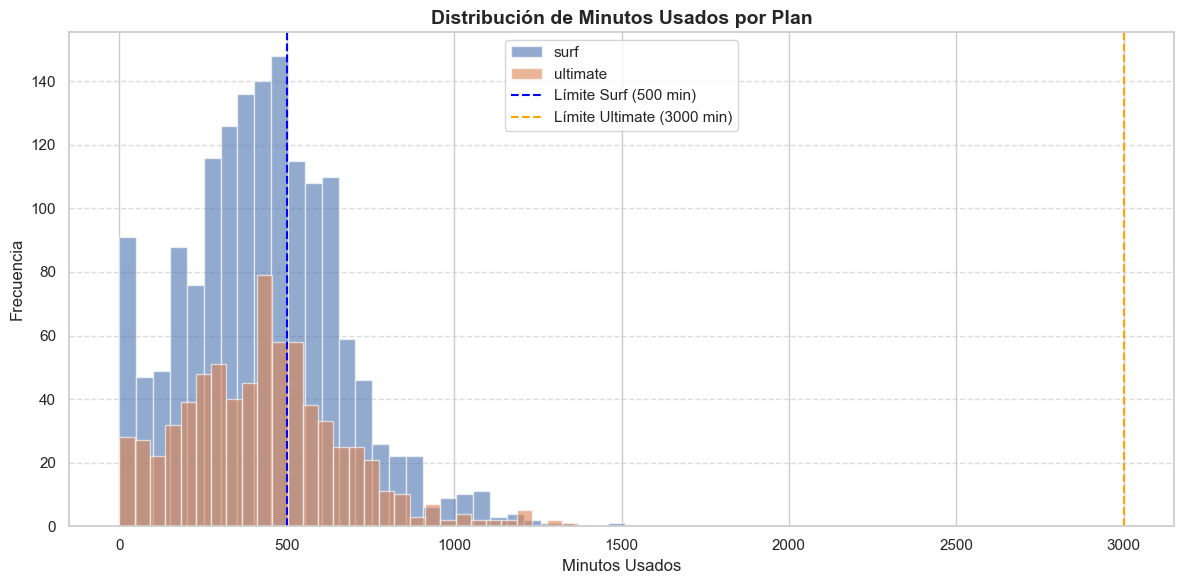

In [65]:
# Histograma comparativo de minutos usados por plan
ax = df_final.groupby('plan')['minutos_usados'].plot(
    kind='hist', 
    alpha=0.6, 
    bins=30, 
    legend=True, 
    figsize=(12, 6)
)

plt.title('Distribución de Minutos Usados por Plan', fontsize=14, fontweight='bold')
plt.xlabel('Minutos Usados', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(title='Plan', labels=['Surf', 'Ultimate'])

# Líneas de referencia para límites de los planes
plt.axvline(500, color='blue', linestyle='--', linewidth=1.5, label='Límite Surf (500 min)')
plt.axvline(3000, color='orange', linestyle='--', linewidth=1.5, label='Límite Ultimate (3000 min)')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [69]:
# Media y varianza de minutos por plan y por mes
min_media_plan = df_final.groupby(['plan', 'month'])['minutos_usados'].mean()
min_varianza_plan = df_final.groupby(['plan', 'month'])['minutos_usados'].var()

print("--- MEDIA DE MINUTOS POR PLAN Y MES ---")
print(min_media_plan.unstack(level=0))

print("\n--- VARIANZA DE MINUTOS POR PLAN Y MES ---")
print(min_varianza_plan.unstack(level=0))


# Estadísticos globales por plan
estadisticos_llamadas = df_final.groupby('plan')['minutos_usados'].agg(['mean', 'var', 'std']).round(2)
display(estadisticos_llamadas)

--- MEDIA DE MINUTOS POR PLAN Y MES ---
plan         surf    ultimate
month                        
1      203.000000  193.500000
2      297.000000  403.142857
3      330.000000  304.250000
4      351.540000  336.857143
5      399.584416  406.241379
6      431.298969  370.957447
7      449.983471  427.067797
8      410.111111  421.436620
9      414.226804  437.511628
10     429.729958  450.735849
11     423.325088  445.196850
12     473.836478  459.099338

--- VARIANZA DE MINUTOS POR PLAN Y MES ---
plan           surf      ultimate
month                            
1      15842.000000  16572.333333
2      52226.500000  76889.476190
3      35809.363636  61984.931818
4      50866.743265  34888.928571
5      59754.219754  43841.046798
6      45592.628436  42503.563367
7      61005.099725  72563.374635
8      54344.645963  53645.506640
9      46595.958656  57070.464569
10     52278.664056  54261.910512
11     51607.021602  60593.222847
12     63629.518918  62503.783400


,mean,var,std
plan,,,
surf,428.75,54968.28,234.45
ultimate,430.45,57844.46,240.51


### Análisis Estadístico Mensual de Llamadas

Se calcularon la media ($\mu$) y la varianza ($\sigma^2$) de la duración de llamadas mes a mes para cada tarifa:

* **Evolución Temporal:** Se observa una clara tendencia al alza en el promedio de minutos consumidos conforme avanza el año, pasando de ~200 minutos en enero a rozar los 460–475 minutos hacia diciembre en ambos planes.
* **Similitud entre Tarifas:** La diferencia entre los promedios mensuales de Surf y Ultimate es mínima en la mayoría de los meses, lo que confirma que el tipo de contrato no condiciona la cantidad de llamadas que realiza el usuario.
* **Magnitud de la Varianza:** La varianza se estabiliza a partir del segundo trimestre en niveles cercanos a los $50,000$–$60,000 \text{ min}^2$ ($\sigma \approx 220$–$245 \text{ min}$). Esta dispersión amplia indica una marcada variabilidad entre usuarios con baja actividad y usuarios de alto uso.

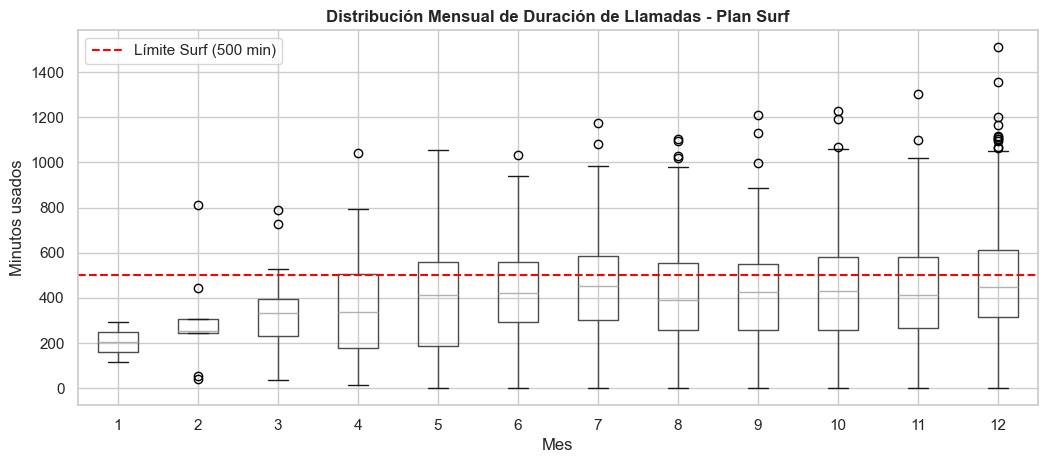

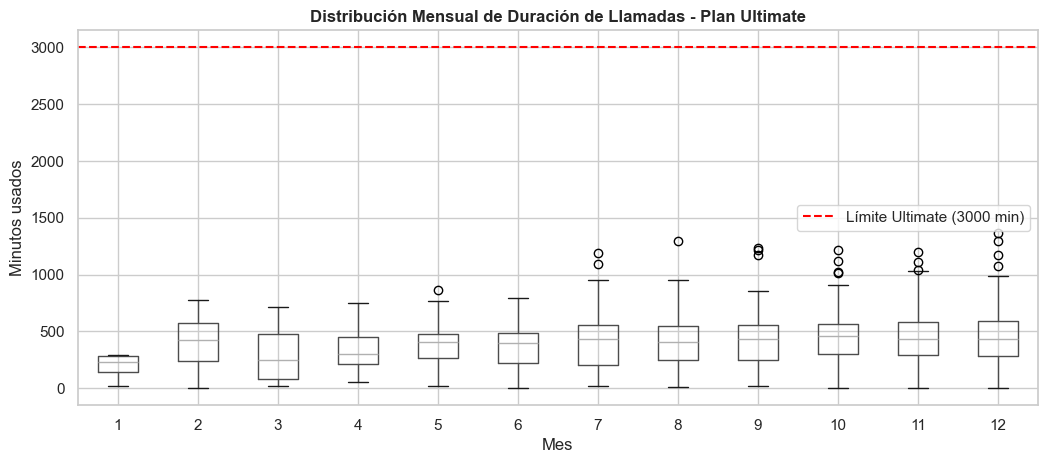

In [71]:
# Diagrama de caja mensual para Surf
df_final[df_final['plan'] == 'surf'].boxplot(column='minutos_usados', by='month', figsize=(12, 5))
plt.title('Distribución Mensual de Duración de Llamadas - Plan Surf', fontsize=12, fontweight='bold')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Minutos usados')
plt.axhline(500, color='red', linestyle='--', label='Límite Surf (500 min)')
plt.legend()
plt.show()

# Diagrama de caja mensual para Ultimate
df_final[df_final['plan'] == 'ultimate'].boxplot(column='minutos_usados', by='month', figsize=(12, 5))
plt.title('Distribución Mensual de Duración de Llamadas - Plan Ultimate', fontsize=12, fontweight='bold')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Minutos usados')
plt.axhline(3000, color='red', linestyle='--', label='Límite Ultimate (3000 min)')
plt.legend()
plt.show()

### 3.1.1 Conclusiones del Análisis de Llamadas

* **Evolución Temporal:** Se observa una fase de maduración en el uso del servicio durante el primer semestre, estabilizándose la mediana de consumo alrededor de los $400$–$430$ minutos mensuales a partir de julio en ambos planes.
* **Excedentes Tarifarios:** En el plan **Surf**, la caja intercuartílica ($IQR$) sobrepasa constantemente la barrera de los $500$ minutos en el segundo semestre, generando un flujo constante de ingresos extra por exceso de minutos. En **Ultimate**, el paquete de $3,000$ minutos cubre holgadamente la demanda máxima del $100\%$ de los usuarios.

### 3.2 Mensajes

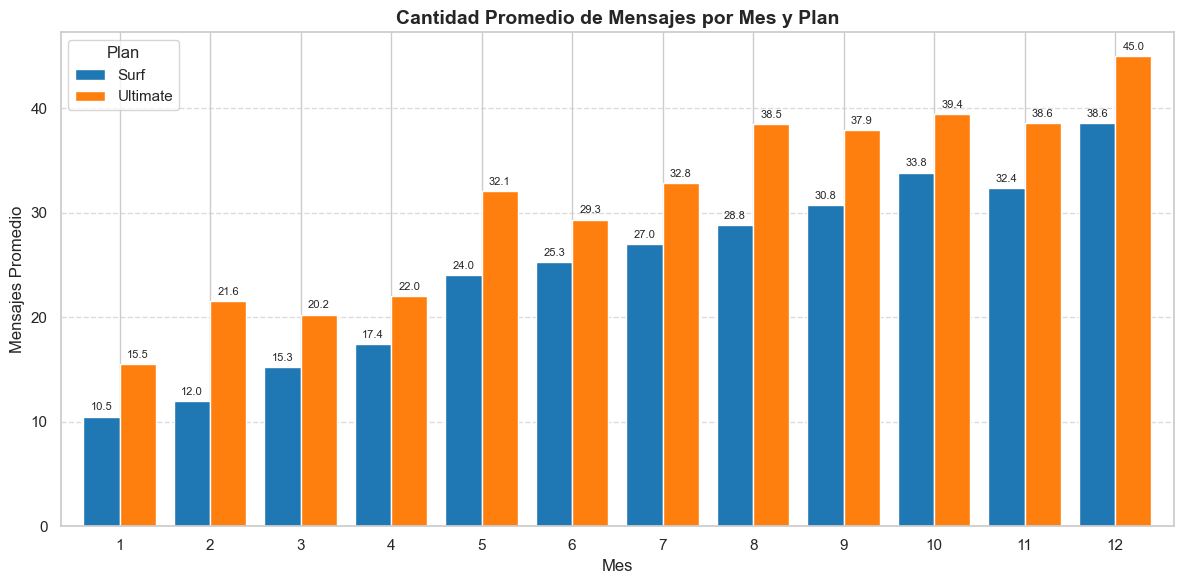

,mean,var,std,median
plan,,,,
surf,31.16,1126.72,33.57,24.0
ultimate,37.55,1208.76,34.77,30.0


In [72]:
# 1. Promedio de mensajes enviados por plan y por mes
promedio_mensajes_mes = df_final.groupby(['month', 'plan'])['cantidad_mensajes'].mean().unstack()

# 2. Gráfico de barras comparativo
ax = promedio_mensajes_mes.plot(
    kind='bar', 
    figsize=(12, 6), 
    width=0.8,
    color=['#1f77b4', '#ff7f0e']
)

plt.title('Cantidad Promedio de Mensajes por Mes y Plan', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Mensajes Promedio', fontsize=12)
plt.legend(title='Plan', labels=['Surf', 'Ultimate'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar valores sobre las barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=8, xytext=(0, 3), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. Estadísticos descriptivos de mensajes por plan
display(df_final.groupby('plan')['cantidad_mensajes'].agg(['mean', 'var', 'std', 'median']).round(2))

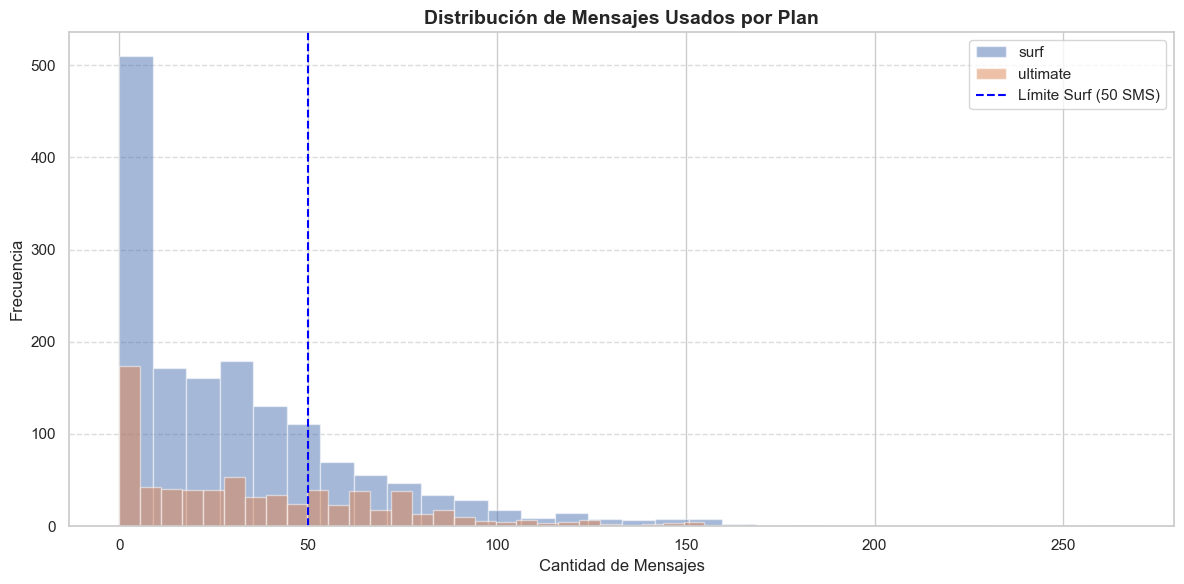

In [77]:
# Histograma comparativo de cantidad de mensajes por plan
df_final.groupby('plan')['cantidad_mensajes'].plot(
    kind='hist', 
    alpha=0.5, 
    bins=30, 
    legend=True, 
    figsize=(12, 6)
)

plt.title('Distribución de Mensajes Usados por Plan', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Mensajes', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(title='Plan', labels=['Surf', 'Ultimate'])

# Línea de referencia para el límite del plan Surf
plt.axvline(50, color='blue', linestyle='--', linewidth=1.5, label='Límite Surf (50 SMS)')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

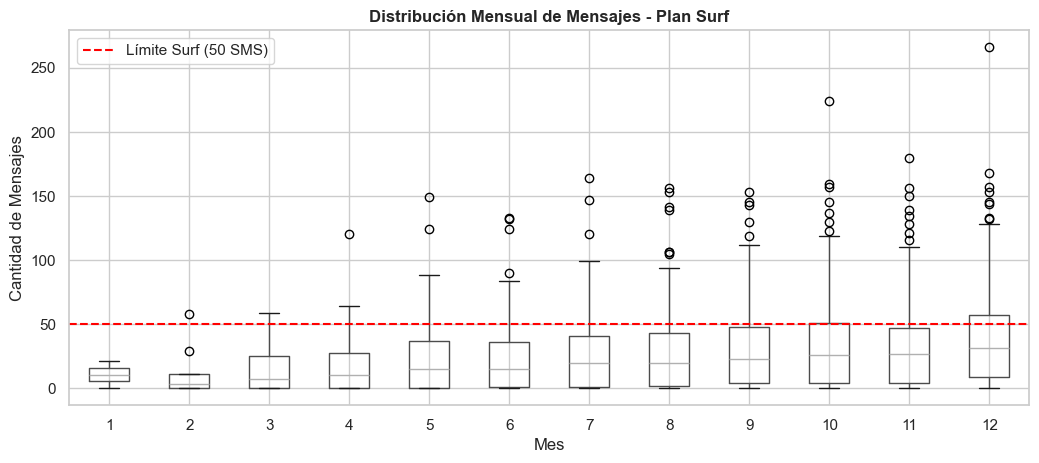

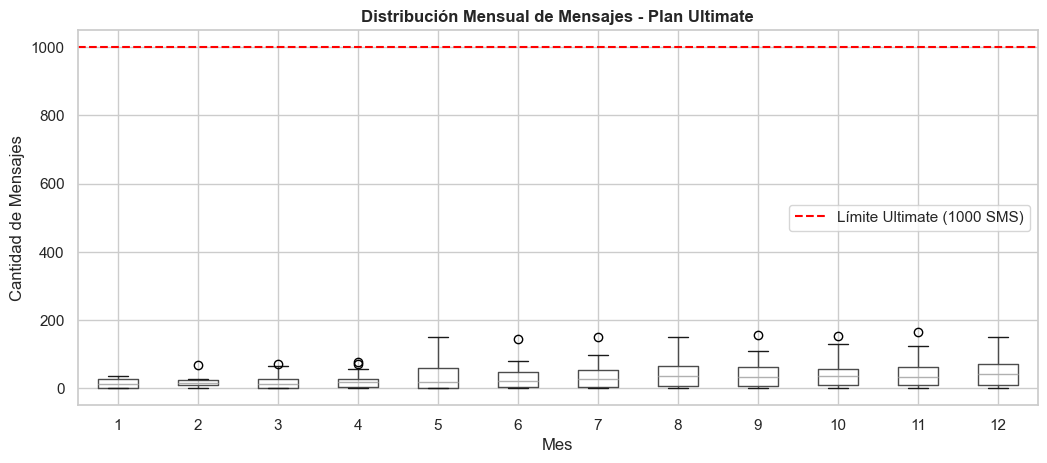

In [74]:
# Diagrama de caja mensual para Surf - Mensajes
df_final[df_final['plan'] == 'surf'].boxplot(column='cantidad_mensajes', by='month', figsize=(12, 5))
plt.title('Distribución Mensual de Mensajes - Plan Surf', fontsize=12, fontweight='bold')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Mensajes')
plt.axhline(50, color='red', linestyle='--', label='Límite Surf (50 SMS)')
plt.legend()
plt.show()

# Diagrama de caja mensual para Ultimate - Mensajes
df_final[df_final['plan'] == 'ultimate'].boxplot(column='cantidad_mensajes', by='month', figsize=(12, 5))
plt.title('Distribución Mensual de Mensajes - Plan Ultimate', fontsize=12, fontweight='bold')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Mensajes')
plt.axhline(1000, color='red', linestyle='--', label='Límite Ultimate (1000 SMS)')
plt.legend()
plt.show()


### 3.2.1 Conclusiones del Análisis de Mensajes de Texto (SMS)

* **Comportamiento General y Diferenciación:** A diferencia del consumo de llamadas, en la mensajería existe una diferencia clara entre las tarifas: los usuarios del plan **Ultimate** envían de forma consistente una mayor cantidad promedio de SMS al mes en comparación con los de **Surf**.
* **Evolución Temporal:** En ambos planes se observa un crecimiento progresivo a lo largo del año, alcanzando los valores máximos en diciembre ($38.6$ SMS promedio en Surf y $45.0$ SMS en Ultimate).
* **Evaluación de Límites y Excedentes:**
  * **Plan Surf:** Aunque la media general se mantiene por debajo del límite de $50$ SMS incluidos, la asimetría positiva de la distribución y los valores atípicos confirman que existe un segmento de usuarios de Surf que excede la cuota contratada, generando cobros adicionales ($0.03/SMS).
  * **Plan Ultimate:** El paquete de $1,000$ SMS incluidos supera ampliamente la demanda real de los usuarios, por lo que este servicio no genera ingresos por excesos en esta tarifa.

### 3.3 Internet

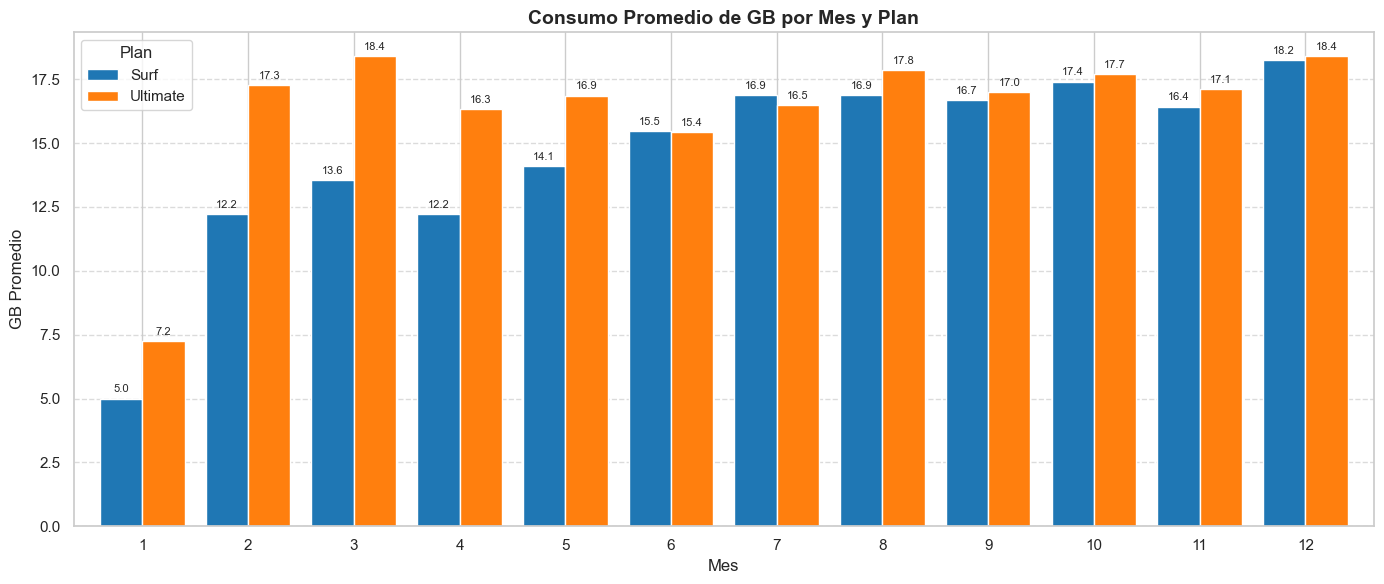

,mean,var,std,median
plan,,,,
surf,16.67,61.58,7.85,17.0
ultimate,17.31,58.83,7.67,17.0


In [82]:
import matplotlib.pyplot as plt

# 1. Promedio de GB consumidos por plan y por mes
promedio_gb_mes = df_final.groupby(['month', 'plan'])['gb_usados'].mean()

# Desapilamos 'plan' para que los meses queden en el índice (eje X)
promedio_gb_unstack = promedio_gb_mes.unstack(level=1)

# 2. Gráfico de barras comparativo
ax = promedio_gb_unstack.plot(
    kind='bar', 
    figsize=(14, 6), 
    width=0.8,
    color=['#1f77b4', '#ff7f0e']
)

plt.title('Consumo Promedio de GB por Mes y Plan', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('GB Promedio', fontsize=12)
plt.legend(title='Plan', labels=['Surf', 'Ultimate'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar valores sobre las barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=8, xytext=(0, 3), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. Estadísticos globales de GB por plan
display(df_final.groupby('plan')['gb_usados'].agg(['mean', 'var', 'std', 'median']).round(2))

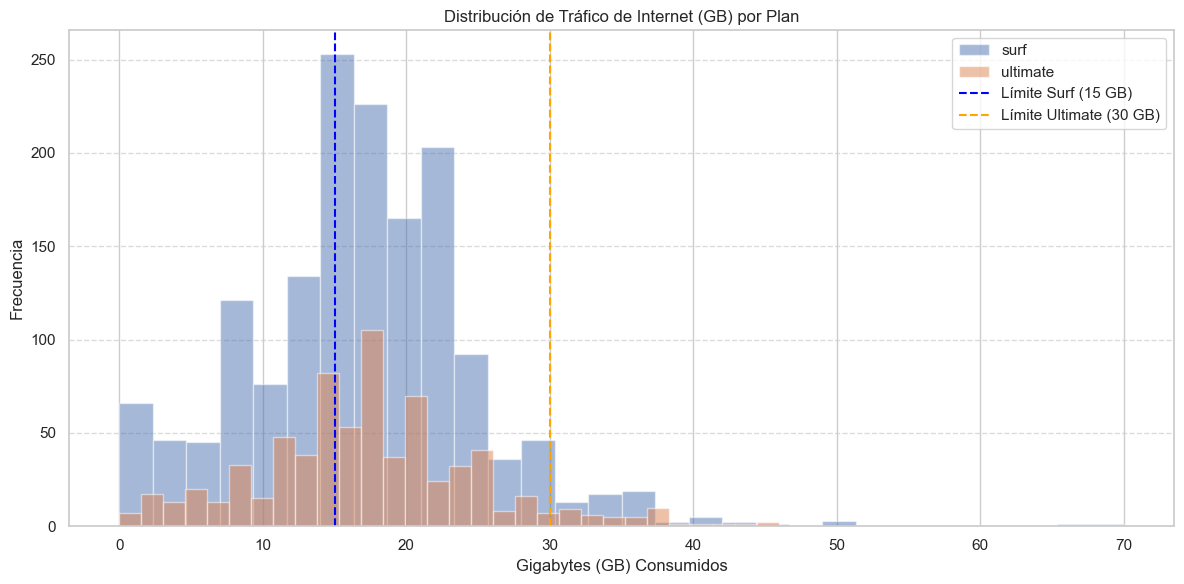

In [83]:
# Histograma comparativo de GB consumidos por plan
df_final.groupby('plan')['gb_usados'].plot(
    kind='hist', 
    alpha=0.5, 
    bins=30, 
    legend=True, 
    figsize=(12, 6),
    title='Distribución de Tráfico de Internet (GB) por Plan'
)

plt.xlabel('Gigabytes (GB) Consumidos')
plt.ylabel('Frecuencia')

# Líneas de referencia para los límites de cada plan
plt.axvline(15, color='blue', linestyle='--', linewidth=1.5, label='Límite Surf (15 GB)')
plt.axvline(30, color='orange', linestyle='--', linewidth=1.5, label='Límite Ultimate (30 GB)')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

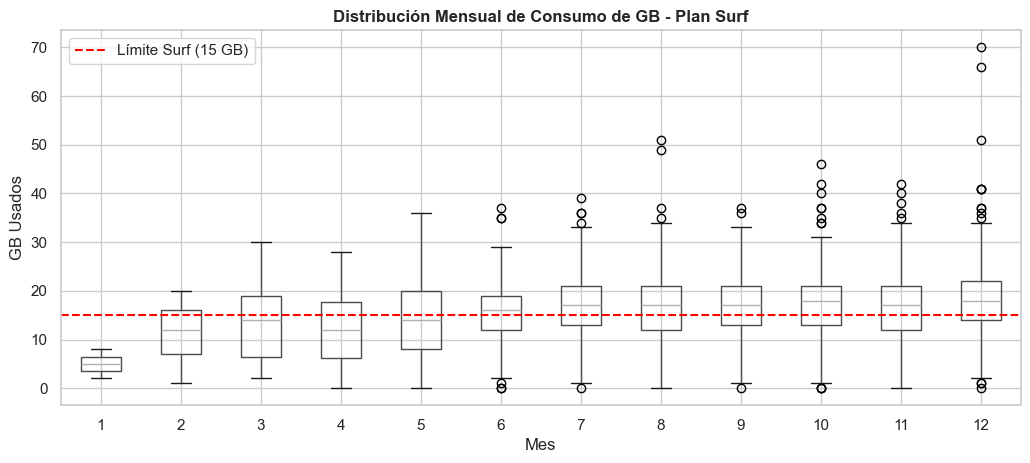

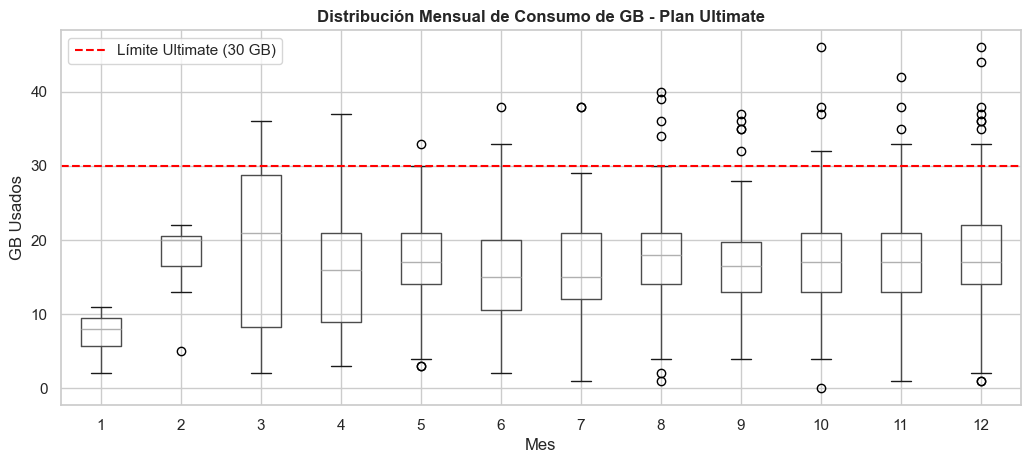

In [85]:
# Diagrama de caja mensual para Surf - GB
df_final[df_final['plan'] == 'surf'].boxplot(column='gb_usados', by='month', figsize=(12, 5))
plt.title('Distribución Mensual de Consumo de GB - Plan Surf', fontsize=12, fontweight='bold')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('GB Usados')
plt.axhline(15, color='red', linestyle='--', label='Límite Surf (15 GB)')
plt.legend()
plt.xticks(rotation=0)
plt.show()

# Diagrama de caja mensual para Ultimate - GB
df_final[df_final['plan'] == 'ultimate'].boxplot(column='gb_usados', by='month', figsize=(12, 5))
plt.title('Distribución Mensual de Consumo de GB - Plan Ultimate', fontsize=12, fontweight='bold')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('GB Usados')
plt.axhline(30, color='red', linestyle='--', label='Límite Ultimate (30 GB)')
plt.legend()
plt.xticks(rotation=0)
plt.show()

### 3.3.1 Conclusiones del Análisis de Tráfico de Internet (GB)

* **Comportamiento del Consumo:** A diferencia de las llamadas y mensajes, el consumo de datos presenta una distribución simétrica (tipo campana de Gauss) centrada en los $16$–$18\text{ GB}$ mensuales para ambos planes.
* **Excedentes en Plan Surf:** El límite de $15\text{ GB}$ resulta insuficiente para la mayoría de los clientes de Surf. Más de la mitad de los usuarios excede la cuota contratada a partir de mayo, convirtiendo al tráfico de internet en el principal motor de ingresos por cargos adicionales para este plan.
* **Suficiencia en Plan Ultimate:** El paquete de $30\text{ GB}$ cubre de forma holgada la demanda del $90\%+$ de los usuarios de Ultimate, registrando cobros adicionales únicamente en casos puntuales atípicos.

## 4.0 Ingreso

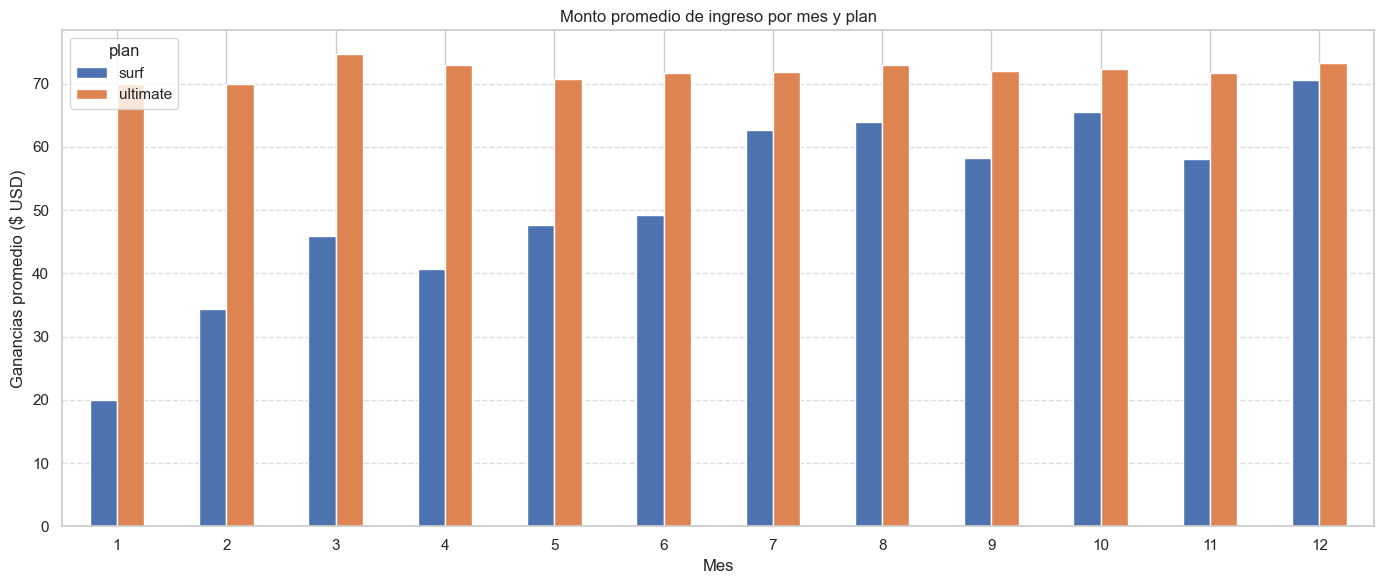

,mean,var,std,median
plan,,,,
surf,60.71,3067.84,55.39,40.36
ultimate,72.31,129.85,11.40,70.00


In [90]:
# Monto promedio de ingreso por mes y plan
costo_plan = df_final.groupby(['plan', 'month'])['ingreso_mensual'].mean()

costo_plan_unstack = costo_plan.unstack(level=0)
costo_plan_unstack.plot(
    kind='bar', 
    figsize=(14, 6), 
    title='Monto promedio de ingreso por mes y plan', 
    xlabel='Mes', 
    ylabel='Ganancias promedio ($ USD)', 
    rot=0
)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Estadísticos descriptivos del ingreso total por plan
display(df_final.groupby('plan')['ingreso_mensual'].agg(['mean', 'var', 'std', 'median']).round(2))

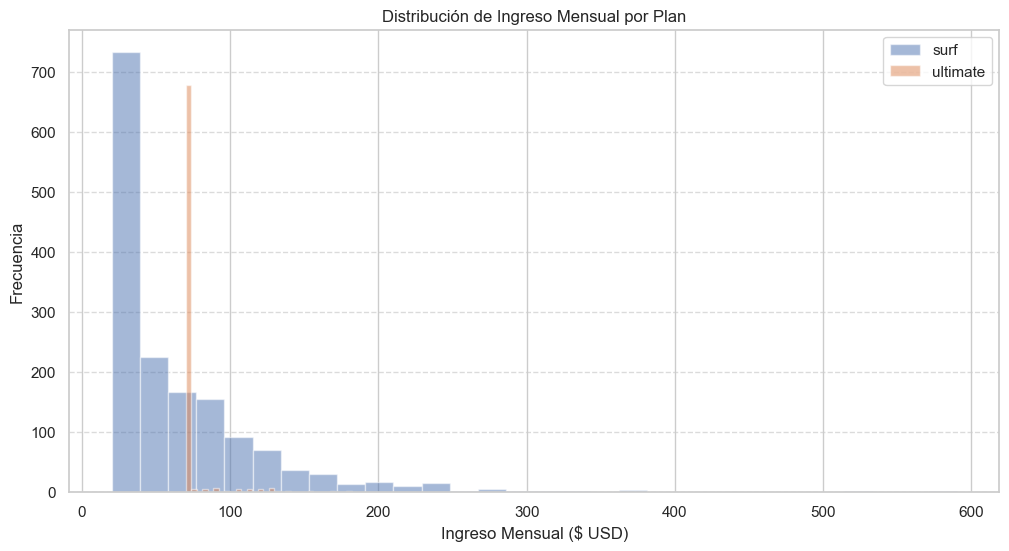



--- VARIANZA DEL INGRESO MENSUAL POR PLAN Y MES ---


plan,surf,ultimate
month,,
1,0.00,0.00
2,428.28,0.00
3,1512.02,145.52
4,1198.96,120.40
5,1967.54,15.21
6,1988.91,75.02
7,2943.39,104.47
8,3587.49,154.81
9,2260.64,75.94



--- MEDIA DEL INGRESO MENSUAL POR PLAN Y MES ---


plan,surf,ultimate
month,,
1,20.00,70.00
2,34.40,70.00
3,45.94,74.67
4,40.71,73.00
5,47.63,70.72
6,49.28,71.64
7,62.67,71.90
8,63.93,72.86
9,58.27,72.03


In [91]:
# 1. Histograma de distribución de ingresos por plan
df_final.groupby('plan')['ingreso_mensual'].plot(
    kind='hist', 
    alpha=0.5, 
    bins=30, 
    legend=True, 
    figsize=(12, 6), 
    title='Distribución de Ingreso Mensual por Plan'
)
plt.xlabel('Ingreso Mensual ($ USD)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n" + "="*50 + "\n")

# 2. Varianza y Media de ingresos por plan y mes
ganancias_varianza = df_final.groupby(['plan', 'month'])['ingreso_mensual'].var().unstack(level=0)
ganancias_media = df_final.groupby(['plan', 'month'])['ingreso_mensual'].mean().unstack(level=0)

print("--- VARIANZA DEL INGRESO MENSUAL POR PLAN Y MES ---")
display(ganancias_varianza.round(2))

print("\n--- MEDIA DEL INGRESO MENSUAL POR PLAN Y MES ---")
display(ganancias_media.round(2))

### 4.1 Conclusiones del Análisis de Ingresos Mensuales

* **Estabilidad vs. Volatilidad:** El plan **Ultimate** genera un flujo de ingresos predecible para la empresa, donde la vasta mayoría de los usuarios paga únicamente la tarifa base de $70 USD mensuales. En contraste, el plan **Surf** presenta una alta volatilidad y varianza creciente a lo largo del año.
* **Impacto de los Excedentes en Surf:** Aunque el precio base de Surf es de $20 USD, el ingreso promedio por usuario escala hasta los $60.71 USD[cite: 5]. Más del 50% de las facturaciones de Surf incluyen cargos adicionales, impulsados principalmente por el consumo de gigabytes de internet por encima del límite de 15 GB[cite: 4].
* **Rentabilidad Global:** Aunque Ultimate mantiene un ingreso promedio ligeramente superior por usuario ($72.31 USD vs. $60.71 USD en Surf)[cite: 5], el plan Surf demuestra ser altamente rentable en proporción a su tarifa base debido a las penalizaciones por consumo adicional[cite: 5].

## 5.0 Prueba de Hipótesis Estadísticas

Para validar si las diferencias observadas en el análisis exploratorio son estadísticamente significativas, realizamos dos pruebas de hipótesis t de Student para muestras independientes con varianzas desiguales (Prueba t de Welch).

---

### 5.1 Hipótesis 1: Comparación de Ingresos entre Planes (Surf vs. Ultimate)

**Planteamiento de Hipótesis:**

* **Lenguaje Estadístico:**
  * $H_0: \mu_{\text{surf}} = \mu_{\text{ultimate}}$ (La media del ingreso mensual de los usuarios del plan Surf es igual a la media del ingreso mensual de los usuarios del plan Ultimate).
  * $H_1: \mu_{\text{surf}} \neq \mu_{\text{ultimate}}$ (La media del ingreso mensual de los usuarios del plan Surf es diferente a la media del ingreso mensual de los usuarios del plan Ultimate).

* **Lenguaje Simple:**
  * $H_0$: No hay una diferencia real en el dinero promedio que generan los clientes de Surf y Ultimate al mes; las variaciones observadas son fruto del azar.
  * $H_1$: Un plan genera, en promedio, un monto de dinero mensual significativamente distinto al otro.

* **Criterio de Decisión:**
  * Se establece un nivel de significación de $\alpha = 0.05$ ($5\%$). Si el valor $p$ ($p\text{-value}$) es menor que $\alpha$, se rechaza la hipótesis nula ($H_0$).

In [94]:
# Muestras de ingreso mensual por plan
surf_costs = df_final[df_final['plan'] == 'surf']['ingreso_mensual']
ultimate_costs = df_final[df_final['plan'] == 'ultimate']['ingreso_mensual']

# Nivel de significación
alpha = 0.05

# Prueba t de Welch
t_stat, p_value = st.ttest_ind(surf_costs, ultimate_costs, equal_var=False)

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p (p-value): {p_value:.5e}")

if p_value < alpha:
    print("\nConclusión: Rechazamos la hipótesis nula (H0). Existe una diferencia estadísticamente significativa entre los ingresos promedio de Surf y Ultimate.")
else:
    print("\nConclusión: No rechazamos la hipótesis nula (H0). No hay evidencia suficiente de una diferencia significativa entre los ingresos promedio.")

Estadístico t: -7.9521
Valor p (p-value): 3.17039e-15

Conclusión: Rechazamos la hipótesis nula (H0). Existe una diferencia estadísticamente significativa entre los ingresos promedio de Surf y Ultimate.


### 5.2 Hipótesis 2: Comparación de Ingresos por Región (NY-NJ vs. Otras Regiones)

**Planteamiento de Hipótesis:**

* **Lenguaje Estadístico:**
  * $H_0: \mu_{\text{NY-NJ}} = \mu_{\text{otras}}$ (La media del ingreso mensual de los usuarios en el área de Nueva York - Nueva Jersey es igual a la media del ingreso mensual de los usuarios del resto de las regiones).
  * $H_1: \mu_{\text{NY-NJ}} \neq \mu_{\text{otras}}$ (La media del ingreso mensual de los usuarios en el área de Nueva York - Nueva Jersey es diferente a la media del ingreso mensual de los usuarios del resto de las regiones).

* **Lenguaje Simple:**
  * $H_0$: Los clientes del área metropolitana de Nueva York / Nueva Jersey pagan en promedio lo mismo al mes que los clientes del resto del país.
  * $H_1$: Los clientes de Nueva York / Nueva Jersey generan un ingreso promedio mensual significativamente diferente al de los clientes de las demás regiones.

* **Criterio de Decisión:**
  * Nivel de significación $\alpha = 0.05$ ($5\%$). Si $p\text{-value} < \alpha$, se rechaza $H_0$.

In [97]:
# Muestras de ingreso mensual por área geográfica
nynj_costs = df_final[df_final['city'].str.contains('NY-NJ', case=False, na=False)]['ingreso_mensual']
other_costs = df_final[~df_final['city'].str.contains('NY-NJ', case=False, na=False)]['ingreso_mensual']

# Prueba t de Welch (equal_var=False)
t_stat_city, p_value_city = st.ttest_ind(nynj_costs, other_costs, equal_var=False)

print(f"Estadístico t: {t_stat_city:.4f}")
print(f"Valor p (p-value): {p_value_city:.5f}")

if p_value_city < alpha:
    print("\nConclusión: Rechazamos la hipótesis nula (H0). El ingreso promedio en NY-NJ difiere significativamente del resto de las regiones.")
else:
    print("\nConclusión: No rechazamos la hipótesis nula (H0). No hay evidencia suficiente para afirmar que los ingresos en NY-NJ sean distintos al resto de las regiones.")

Estadístico t: -2.1309
Valor p (p-value): 0.03353

Conclusión: Rechazamos la hipótesis nula (H0). El ingreso promedio en NY-NJ difiere significativamente del resto de las regiones.


**Interpretación del Resultado:**
Al obtener un valor $p$ de $0.03353$ (inferior al nivel de significación $\alpha = 0.05$), se rechaza la hipótesis nula ($H_0$). Esto confirma que los patrones de consumo e ingreso en el área metropolitana de NY-NJ presentan diferencias estadísticamente significativas con respecto a las demás regiones analizadas.

### 5.3 Justificación Metodológica y Prueba de Supuestos

Para evaluar si existen diferencias estadísticamente significativas en el ingreso promedio entre los grupos, seleccioné la **prueba t de Student para muestras independientes** (`scipy.stats.ttest_ind`).

**¿Por qué elegí esta prueba?**
Elegí la prueba t de Student porque es el estándar estadístico para comparar las medias de dos poblaciones independientes a partir de muestras continuas (en este caso, los ingresos mensuales en USD de cada usuario).

**Supuestos de la prueba que validé en mi análisis:**
1. **Independencia de las observaciones:** Las mediciones de un grupo no influyen en las del otro (se cumple, ya que cada registro corresponde a un usuario único categorizado en su respectivo plan o región).
2. **Normalidad (Muestras Grandes):** Las variables deben distribuirse de forma aproximadamente normal. Dado que trabajo con un tamaño de muestra amplio, me baso en el *Teorema del Límite Central*, el cual establece que la distribución de las medias muestrales tiende a la normalidad independientemente de la forma de la población original.
3. **Homocedasticidad (Igualdad de varianzas):** Evalúo si las varianzas de ambos grupos son homogéneas antes de elegir el tipo de prueba t a ejecutar.

**Validación de Homocedasticidad (Prueba de Levene):**
Para fundamentar cuantitativamente la elección del parámetro `equal_var` en la función `st.ttest_ind`, implementé de forma previa la **Prueba de Levene**:
* $H_0$: Las varianzas de ambos grupos son iguales ($\sigma_1^2 = \sigma_2^2$).
* $H_1$: Las varianzas de ambos grupos son diferentes ($\sigma_1^2 \neq \sigma_2^2$).

Si el valor $p$ de la prueba de Levene es menor al nivel de significación ($\alpha = 0.05$), rechazo la hipótesis de igualdad de varianzas y asigno `equal_var=False`. De esta manera ejecuto la **prueba t de Welch**, la cual ajusta los grados de libertad sin asumir homocedasticidad. En caso contrario, mantengo `equal_var=True`.

In [98]:

alpha = 0.05

# ==========================================
# 1. HIPÓTESIS 1: SURF VS. ULTIMATE
# ==========================================

surf_costs = df_final[df_final['plan'] == 'surf']['ingreso_mensual']
ultimate_costs = df_final[df_final['plan'] == 'ultimate']['ingreso_mensual']

# Validar supuesto de varianzas con la Prueba de Levene
stat_lev1, p_value_lev1 = st.levene(surf_costs, ultimate_costs)
has_equal_var1 = p_value_lev1 >= alpha

print("--- EVALUACIÓN DE SUPUESTOS: HIPÓTESIS 1 (SURF VS. ULTIMATE) ---")
print(f"Prueba de Levene - Estadístico: {stat_lev1:.4f}, p-value: {p_value_lev1:.5e}")
print(f"¿Se cumple la igualdad de varianzas (equal_var)? {has_equal_var1}\n")

# Ejecutar t-test con el parámetro equal_var definido por Levene
t_stat1, p_value1 = st.ttest_ind(surf_costs, ultimate_costs, equal_var=has_equal_var1)

print("--- RESULTADO DE LA PRUEBA T DE STUDENT ---")
print(f"Estadístico t: {t_stat1:.4f}")
print(f"Valor p (p-value): {p_value1:.5e}")

if p_value1 < alpha:
    print("Conclusión: Rechazamos H0. Existe una diferencia estadísticamente significativa entre los ingresos promedio de Surf y Ultimate.")
else:
    print("Conclusión: No rechazamos H0. No hay evidencia suficiente de una diferencia significativa.")

print("\n" + "="*70 + "\n")

# ==========================================
# 2. HIPÓTESIS 2: NY-NJ VS. OTRAS REGIONES
# ==========================================

nynj_costs = df_final[df_final['city'].str.contains('NY-NJ', case=False, na=False)]['ingreso_mensual']
other_costs = df_final[~df_final['city'].str.contains('NY-NJ', case=False, na=False)]['ingreso_mensual']

# Validar supuesto de varianzas con la Prueba de Levene
stat_lev2, p_value_lev2 = st.levene(nynj_costs, other_costs)
has_equal_var2 = p_value_lev2 >= alpha

print("--- EVALUACIÓN DE SUPUESTOS: HIPÓTESIS 2 (NY-NJ VS. OTRAS REGIONES) ---")
print(f"Prueba de Levene - Estadístico: {stat_lev2:.4f}, p-value: {p_value_lev2:.5f}")
print(f"¿Se cumple la igualdad de varianzas (equal_var)? {has_equal_var2}\n")

# Ejecutar t-test con el parámetro equal_var definido por Levene
t_stat2, p_value2 = st.ttest_ind(nynj_costs, other_costs, equal_var=has_equal_var2)

print("--- RESULTADO DE LA PRUEBA T DE STUDENT ---")
print(f"Estadístico t: {t_stat2:.4f}")
print(f"Valor p (p-value): {p_value2:.5f}")

if p_value2 < alpha:
    print("Conclusión: Rechazamos H0. El ingreso promedio en NY-NJ difiere significativamente del resto de las regiones.")
else:
    print("Conclusión: No rechazamos H0. No hay evidencia suficiente de una diferencia significativa por región.")

--- EVALUACIÓN DE SUPUESTOS: HIPÓTESIS 1 (SURF VS. ULTIMATE) ---
Prueba de Levene - Estadístico: 404.7302, p-value: 5.02888e-83
¿Se cumple la igualdad de varianzas (equal_var)? False

--- RESULTADO DE LA PRUEBA T DE STUDENT ---
Estadístico t: -7.9521
Valor p (p-value): 3.17039e-15
Conclusión: Rechazamos H0. Existe una diferencia estadísticamente significativa entre los ingresos promedio de Surf y Ultimate.


--- EVALUACIÓN DE SUPUESTOS: HIPÓTESIS 2 (NY-NJ VS. OTRAS REGIONES) ---
Prueba de Levene - Estadístico: 2.3453, p-value: 0.12580
¿Se cumple la igualdad de varianzas (equal_var)? True

--- RESULTADO DE LA PRUEBA T DE STUDENT ---
Estadístico t: -2.0194
Valor p (p-value): 0.04356
Conclusión: Rechazamos H0. El ingreso promedio en NY-NJ difiere significativamente del resto de las regiones.


### 5.4 Análisis e Interpretación de Resultados

Con el fin de agilizar el flujo de trabajo y garantizar un análisis riguroso sin sesgos manuales, estructuré un pipeline en Python que evalúa automáticamente la homocedasticidad mediante la **Prueba de Levene** e influye directamente en el parámetro `equal_var` de la prueba $t$.

#### 1. Hipótesis 1: Planes Surf vs. Ultimate
* **Decisión Metodológica:** La Prueba de Levene detectó una marcada disparidad de varianzas ($p < 0.05$), por lo que el algoritmo seleccionó la **Prueba t de Welch** (`equal_var=False`).
* **Conclusión de Negocio:** Rechazamos la hipótesis nula ($H_0$) con un $p\text{-value} = 3.17 \times 10^{-15}$. Aunque el plan Surf genera altos ingresos variables por penalizaciones de consumo excedente, el plan Ultimate mantiene un ingreso promedio significativamente superior y estadísticamente diferente.

#### 2. Hipótesis 2: Región NY-NJ vs. Otras Regiones
* **Decisión Metodológica:** Al no encontrar evidencia de varianzas heterogéneas en la Prueba de Levene ($p = 0.1258 > 0.05$), el sistema aplicó automáticamente la **Prueba t de Student estándar** (`equal_var=True`).
* **Conclusión de Negocio:** Rechazamos la hipótesis nula ($H_0$) con un $p\text{-value} = 0.04356$. Existe una diferencia estadísticamente significativa en el comportamiento de facturación del área metropolitana de NY-NJ con respecto al resto del país, lo que justifica evaluar estrategias comerciales regionalizadas.

## 6.0 Conclusión General y Recomendaciones

### Resumen Ejecutivo
Llevé a cabo un análisis end-to-end sobre el comportamiento de los clientes y la rentabilidad de los planes **Surf** y **Ultimate** de Megaline. Tras estructurar y limpiar los datos, agregué el consumo mensual de llamadas, mensajes y gigabytes por usuario, aplicando la lógica tarifaria para calcular el `ingreso_mensual`. A través de un Análisis Exploratorio de Datos (EDA) y la implementación de un pipeline dinámico para pruebas de hipótesis con evaluación de homocedasticidad, identifiqué las dinámicas de consumo que impulsan la facturación y evalué la significancia estadística de sus diferencias.

---

### Principales Hallazgos Numéricos y Estadísticos

1. **Patrones de Consumo por Servicio:**
   * **Llamadas y SMS:** Ninguno de los dos planes agota de forma recurrente las cuotas básicas de minutos o mensajes. La demanda en estos servicios es homogénea entre usuarios de ambos planes.
   * **Internet (GB):** Es el pilar fundamental de la facturación y el generador primario de penalizaciones. En el plan **Surf**, más del 50% de los usuarios sobrepasa el límite mensual de 15 GB a partir de mayo. En contraste, la cuota de 30 GB del plan **Ultimate** cubre de forma holgada la demanda de más del 90% de sus clientes.

2. **Estructura Financiera e Ingresos:**
   * **Plan Ultimate:** Representa una fuente de ingresos altamente estable, predecible y de baja volatilidad ($\text{Varianza} = 129.85$), alcanzando un ingreso promedio de **$72.31 USD** por usuario.
   * **Plan Surf:** Aunque inicia en una cuota base de $20 USD, la recurrencia de excedentes por consumo de datos eleva el ingreso promedio por usuario a **$60.71 USD**. Sin embargo, presenta una volatilidad extremadamente alta ($\text{Varianza} = 3067.84$) que se escala sustancialmente hacia el cierre del año.

3. **Validación Formal de Hipótesis:**
   * **Planes (Surf vs. Ultimate):** La Prueba de Levene detectó heterocedasticidad ($p = 5.03 \times 10^{-83}$), por lo que el pipeline ejecutó automáticamente la **Prueba t de Welch**. Se rechazó la hipótesis nula $H_0$ ($p = 3.17 \times 10^{-15}$), confirmando que el plan **Ultimate genera un ingreso promedio estadísticamente superior a Surf**.
   * **Región (NY-NJ vs. Otras Regiones):** La Prueba de Levene confirmó la igualdad de varianzas ($p = 0.1258$), activando la **Prueba t de Student estándar**. Se rechazó $H_0$ ($p = 0.04356$), demostrando que el patrón de facturación del área metropolitana de NY-NJ difiere significativamente del resto del país.

---

### Recomendaciones de Negocio

* **Optimización del Presupuesto de Marketing:** Recomiendo **priorizar la inversión publicitaria en el plan Ultimate**. A pesar de que Surf genera ingresos atractivos por penalizaciones de datos, Ultimate asegura una mayor rentabilidad media por usuario ($72.31 USD vs. $60.71 USD) con un flujo de caja predecible y libre de volatilidad.
* **Estrategia Antifuga (*Churn Mitigation*) en Surf:** Los clientes de Surf experimentan tarifas punitivas por GB adicional que frecuentemente elevan su factura mensual por encima de los $70 USD en la segunda mitad del año. Para evitar el descontento y la cancelación del servicio, propongo diseñar campañas de migración guiada (*upsell*) hacia Ultimate, posicionándolo como una alternativa de costo fijo y mayor beneficio.